## Step 1: Load the Dataset & Clean it.

In [67]:
import pandas as pd
df1 = pd.read_csv('loan_approval.csv')
df1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [69]:
df1.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [54]:
df1.duplicated().sum()

0

In [104]:
df1.shape

(614, 13)

In [71]:
df1.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [75]:
df2 = df1.copy(deep = True)


df2['Total_Income'] = df2['ApplicantIncome'] + df2['CoapplicantIncome']


df2.drop(['Loan_ID', 'CoapplicantIncome'], axis = 1, inplace = True)


fill_values = {}


fill_values['LoanAmount'] = df2['LoanAmount'].median()


categorical_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 
                       'Loan_Amount_Term', 'Credit_History', 'Property_Area']

for col in categorical_columns:
    mode_value = df2[col].mode()
    
    if not mode_value.empty:
        fill_values[col] = mode_value[0]
    else:
        fill_values[col] = 'Unknown'  


df2.fillna(fill_values, inplace=True)

In [77]:
df2.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0,Graduate,No,5849,128.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,4583,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,3000,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,2583,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,6000,141.0,360.0,1.0,Urban,Y,6000.0


In [79]:
df2.isnull().sum()

Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
ApplicantIncome     0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Loan_Status         0
Total_Income        0
dtype: int64

In [81]:
df2.dtypes

Gender               object
Married              object
Dependents           object
Education            object
Self_Employed        object
ApplicantIncome       int64
LoanAmount          float64
Loan_Amount_Term    float64
Credit_History      float64
Property_Area        object
Loan_Status          object
Total_Income        float64
dtype: object

In [106]:
df2.shape

(614, 12)

## Step 2: Preprocess the Data.

In [117]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

categorical_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 
                       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

numerical_columns = ['LoanAmount', 'ApplicantIncome']

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipeline, categorical_columns),
        ('num', numerical_pipeline, numerical_columns)
    ])

X_processed = preprocessor.fit_transform(df2)

cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_columns)


all_feature_names = list(cat_feature_names) + numerical_columns

df4_transformed = pd.DataFrame(X_processed, columns=all_feature_names)

In [129]:
df4_transformed.head(10)

,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Loan_Amount_Term_36.0,Loan_Amount_Term_60.0,Loan_Amount_Term_84.0,...,Loan_Amount_Term_240.0,Loan_Amount_Term_300.0,Loan_Amount_Term_360.0,Loan_Amount_Term_480.0,Credit_History_1.0,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y,LoanAmount,ApplicantIncome
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,-0.211241,0.072991
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.211241,-0.134412
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,-0.948996,-0.393747
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,-0.306435,-0.462062
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,-0.056551,0.097728
5,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.442758,0.002218
6,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,-0.603917,-0.503019
7,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.145737,-0.387850
8,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.264730,-0.228939
9,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,2.418499,1.218457


In [123]:
df4_transformed.shape

(614, 22)

In [125]:
df4_transformed.columns

Index(['Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2',
       'Dependents_3+', 'Education_Not Graduate', 'Self_Employed_Yes',
       'Loan_Amount_Term_36.0', 'Loan_Amount_Term_60.0',
       'Loan_Amount_Term_84.0', 'Loan_Amount_Term_120.0',
       'Loan_Amount_Term_180.0', 'Loan_Amount_Term_240.0',
       'Loan_Amount_Term_300.0', 'Loan_Amount_Term_360.0',
       'Loan_Amount_Term_480.0', 'Credit_History_1.0',
       'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Status_Y',
       'LoanAmount', 'ApplicantIncome'],
      dtype='object')

## Step 3: Model Training.

In [127]:
X = df4_transformed.drop('Loan_Status_Y', axis = 1)
y = df4_transformed['Loan_Status_Y']

In [167]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [171]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [175]:
loan_prediction_model = LogisticRegression()
loan_prediction_model.fit(X_train, y_train)

LogisticRegression()

In [185]:
y_pred_proba = loan_prediction_model.predict_proba(X_test)[:, 1]

In [189]:
y_pred_labels = (y_pred_proba >= 0.5).astype(int)
y_pred_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [193]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_continuous = loan_prediction_model.predict(X_test)

y_pred = (y_pred_continuous >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7886178861788617
Confusion Matrix:
 [[18 25]
 [ 1 79]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.42      0.58        43
         1.0       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [201]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.,
       1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1.])

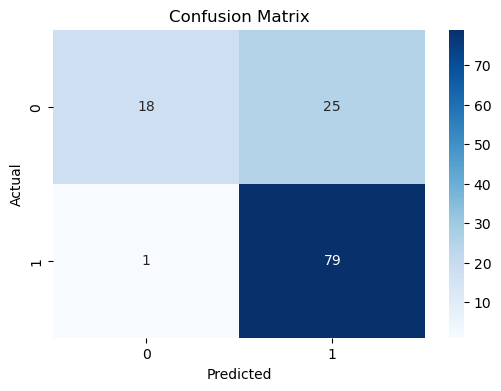

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## ROC Curve.

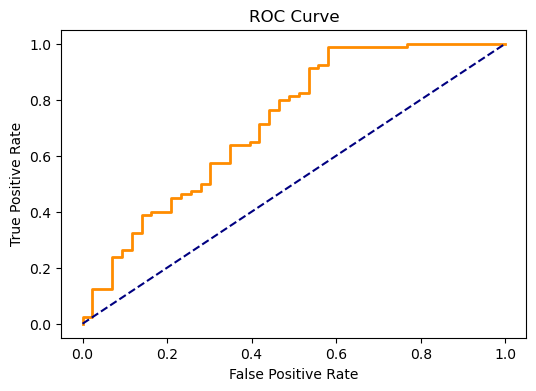

ROC AUC Score: 0.7186046511627907


In [207]:
from sklearn.metrics import roc_curve, roc_auc_score


y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2)
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_probs))

## Feature Importance.

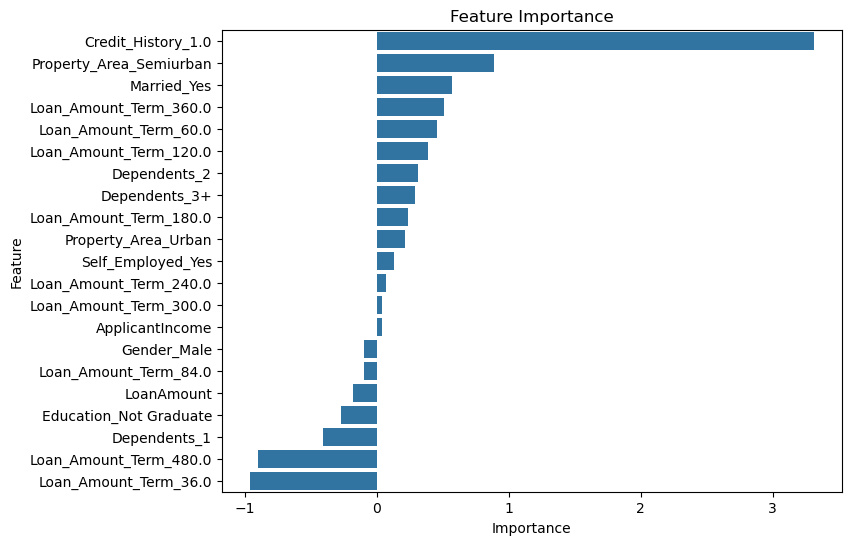

In [209]:
importance = model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

In [211]:
import joblib

joblib.dump(loan_prediction_model, 'loan_prediction_model.pkl')

loaded_model = joblib.load('loan_prediction_model.pkl')

y_pred_loaded = loaded_model.predict(X_test)


In [213]:
import pickle

with open('loan_prediction_model.pkl', 'wb') as file:
    pickle.dump(loan_prediction_model, file)


with open('loan_prediction_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

y_pred_loaded = loaded_model.predict(X_test)

In [215]:
y_pred_loaded = loaded_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy of loaded model:", accuracy_score(y_test, y_pred_loaded))

Accuracy of loaded model: 0.7886178861788617


In [219]:
y_prob = model.predict_proba(X_test)[:, 1] 
auc = roc_auc_score(y_test, y_prob)
print("AUC: ", auc)

AUC:  0.7186046511627907
